In [12]:
import virtualreactor as vr
from virtualreactor.units import ureg, Q_
import numpy as np
from matplotlib import pyplot as plt
import pint

In [39]:
van_de_vusse=vr.Mechanism(
    species=['a', 'b', 'c', 'd'],
    stoichiometry=np.array([
        #r1, r2, r3
        [-1,  0, -2], # Species a
        [ 1, -1,  0], # Species b
        [ 0,  1,  0], # Species c
        [ 0,  0,  1]  # Species d
        ]),
    pre_exponential_factors = np.array([
        1.0e7,  # A1
        5.0e7,  # A2
        1.0e6   # A3
        ]),
    activation_energies = np.array([
        50_000.0,  # E1
        60_000.0,  # E2
        45_000.0,  # E3
        ])
        *ureg.joule/ureg.mol,

    reaction_enthalpies = np.array([
        -40_000.0,   # ΔH1: A -> B
        -30_000.0,   # ΔH2: B -> C
        -50_000.0    # ΔH3: 2 A -> D
        ])
        *ureg.joule/ureg.mol,

    reaction_entropies = np.array([
        -80.0,  # ΔS1: A -> B
        -100,   # ΔS2: B -> C
        -150    # ΔS3: 2 A -> D
        ])
        *ureg.joule/(ureg.mol*ureg.kelvin),

    reversible = np.array([
    True,
    True,
    True
    ])
)

reactor_list=[
    vr.BatchReactor(),
    vr.PlugFlowReactor(flow_model=vr.ConstantVolumetricFlow(
        0.1*ureg.m**3/ureg.second,
        )),
    vr.PlugFlowReactor(
        flow_model=vr.ConstantVolumetricFlow(
            1.5 * ureg.liter / ureg.minute
        ),
        jacket_temperature=300 * ureg.kelvin,
        overall_heat_transfer_coefficient=(
            300
            * ureg.watt
            / (
                ureg.meter**2
                * ureg.kelvin
            )),
        heat_transfer_area_per_volume=(
            200 / ureg.meter
        ))
    
]
constant_density_heat_capacity=vr.PropertyModel.constant(
        density=1000.0 * ureg.kg/ureg.m**3,
        heat_capacity=4180.0 * ureg.joule/(ureg.kg*ureg.kelvin)
        )

results=[]
xi_list=[300,3,30]
for i in range(3):
    vdv_sim=vr.Simulation(
        mechanism=van_de_vusse,
        reactor=reactor_list[i],
        properties=constant_density_heat_capacity
            )
    vdv_sim_result=vdv_sim.solve(
    initial_state=np.array([
            1,0,0,0,300,0
        ]),
    xi_span=(
        0,xi_list[i]
        )
    )
    results.append(vdv_sim_result)

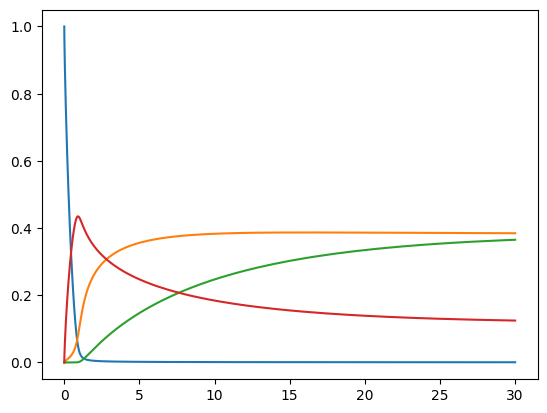

In [42]:
lz=2
t=results[lz]['t']
c=results[lz]['y']
for i in range(4):
    plt.plot(t,c[i])

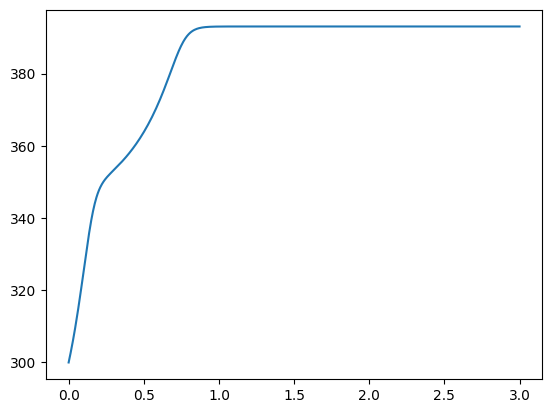

In [26]:
plt.plot(t,c[4])

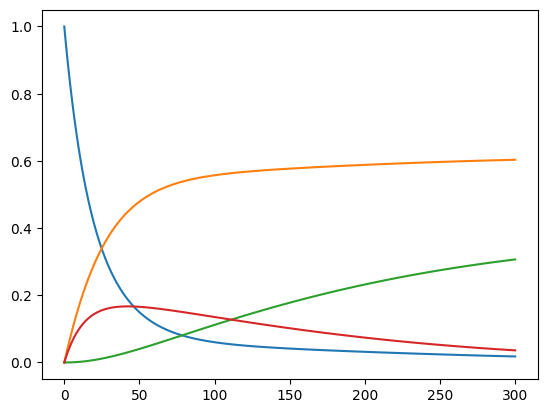

In [15]:
lz=0
t=results[lz]['t']
c=results[lz]['y']
for i in range(4):
    plt.plot(t,c[i])

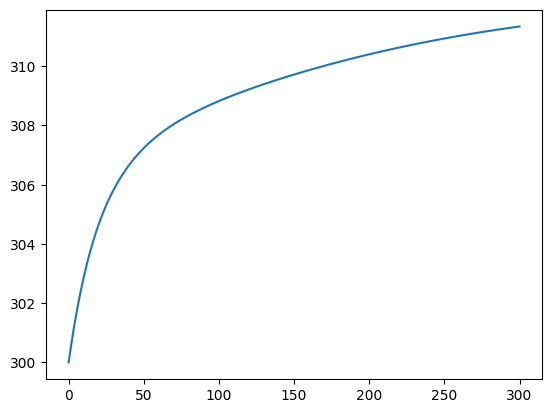

In [17]:
plt.plot(t,c[4])